In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima, ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error, r2_score

In [2]:
df= joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [3]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,NaN,NaN,120.666667,10.263203,NaN,NaN,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,NaN,NaN,126.333333,7.371115,NaN,NaN,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,NaN,NaN,127.333333,5.686241,NaN,NaN,NaN,NaN


In [4]:
df= df.asfreq('MS')

In [5]:
df.isnull().sum()

#Passengers       26
month             26
quater            26
lag1              27
lag2              28
lag3              29
lag6              32
lag12             38
rolling_mean3     28
rolling_std3      28
rolling_mean6     31
rolling_std6      31
rolling_mean12    37
rolling_std12     37
dtype: int64

In [6]:
df.fillna(method='bfill', inplace=True)

C:\Users\MINE\AppData\Local\Temp\ipykernel_3788\3314729575.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [7]:
df.duplicated().sum()

np.int64(26)

In [8]:
df.drop_duplicates(keep='first', inplace=True)

In [9]:
df.shape

(118, 14)

In [10]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112.0,1.0,1.0,112.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-02-01,118.0,2.0,1.0,112.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-03-01,132.0,3.0,1.0,118.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-04-01,129.0,4.0,2.0,132.0,118.0,112.0,112.0,112.0,126.333333,7.371115,124.5,8.916277,124.583333,12.153999
1949-05-01,121.0,5.0,2.0,129.0,132.0,118.0,112.0,112.0,127.333333,5.686241,124.5,8.916277,124.583333,12.153999


In [11]:
train= df.iloc[:-24, :].asfreq('MS')
test= df.iloc[-24:, :].asfreq('MS')

# Arima

In [12]:
arima= auto_arima(
  train['#Passengers'].ffill(),
  seasonal=False
)

In [13]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  115
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -513.536
Date:                Sat, 08 Aug 2026   AIC                           1039.072
Time:                        08:59:34   BIC                           1055.489
Sample:                    01-01-1949   HQIC                          1045.734
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6148      0.158      3.890      0.000       0.305       0.925
ar.L1          1.6384      0.057     28.505      0.000       1.526       1.751
ar.L2         -0.8849      0.049    -18.004      0.000      -0.981      -0.789
ma.L1         -1.7856      0.072    -24.960      0.000      -1.926      -1.645
ma.L2          0.8450      0.071     11.958      0.000       0.707       0.984
sigma2       465.2818     72.874      6.385      0.000     322.452     608.111
===================================================================================
Ljung-Box (L1) (Q):                   0.46   Jarque-Bera (JB):                 2.80
Prob(Q):                              0.50   Prob(JB):                         0.25
Heteroskedasticity (H):               4.98   Skew:                             0.38
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
arima_forecast= arima.predict(len(test))

In [15]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')

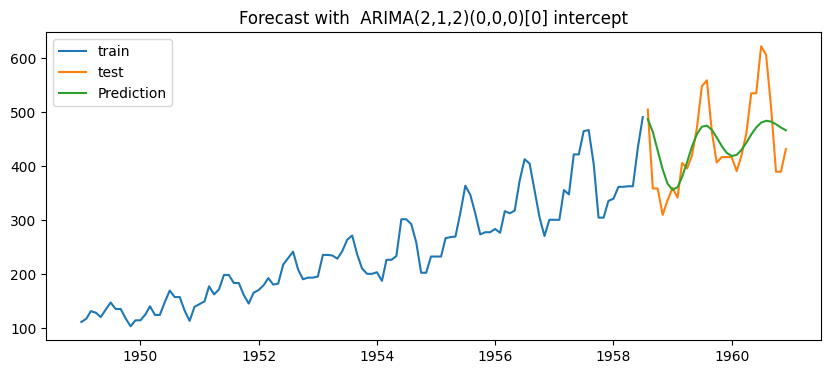

mean absolute error: 45.74
mean absolute percentage error: 10.0%
r2 score: 0.45
root mean squared error: 59.67


In [16]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),arima_forecast, arima)

# Sarima

In [17]:
sarima= auto_arima(train['#Passengers'].ffill(),
                   seasonal=True,
                   m=12)

In [18]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  115
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -439.605
Date:                            Sat, 08 Aug 2026   AIC                            889.211
Time:                                    08:59:54   BIC                            902.385
Sample:                                01-01-1949   HQIC                           894.547
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     20.8756      5.575      3.745      0.000       9.949      31.802
ar.L1          0.6293      0.075      8.368      0.000       0.482       0.777
ar.S.L12      -0.6178      0.086     -7.170      0.000      -0.787      -0.449
ar.S.L24      -0.2318      0.157     -1.478      0.139      -0.539       0.076
sigma2       283.3983     26.720     10.606      0.000     231.028     335.769
===================================================================================
Ljung-Box (L1) (Q):                   0.77   Jarque-Bera (JB):                63.94
Prob(Q):                              0.38   Prob(JB):                         0.00
Heteroskedasticity (H):               5.24   Skew:                             0.67
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.62
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
sarima_pred= sarima.predict(len(test))

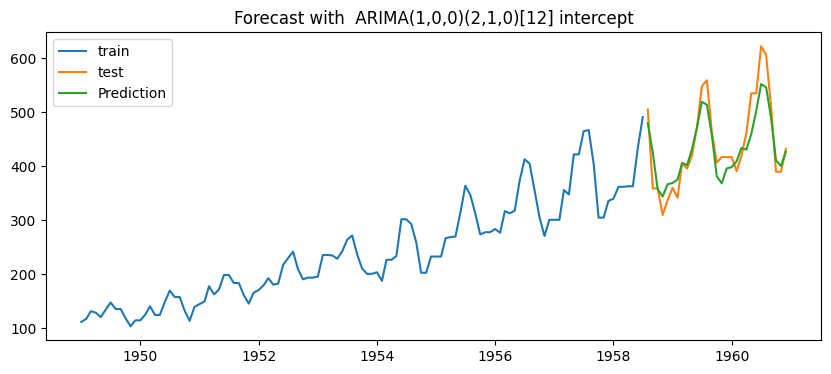

mean absolute error: 26.46
mean absolute percentage error: 6.0%
r2 score: 0.82
root mean squared error: 33.63


In [20]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),sarima_pred, sarima)

# Sarimax

In [21]:
exog_train= train.drop(columns='#Passengers').bfill()
exog_test= test.drop(columns='#Passengers').bfill()

In [22]:
sarimax= auto_arima(train['#Passengers'].ffill(),
                    X= exog_train,
                    m=12,
                    seasonal=True,
                    )

In [23]:
sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  115
Model:               SARIMAX(0, 0, 3)   Log Likelihood                -430.059
Date:                Sat, 08 Aug 2026   AIC                            894.118
Time:                        09:01:15   BIC                            940.781
Sample:                    01-01-1949   HQIC                           913.058
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
month             -2.1072      1.813     -1.162      0.245      -5.660       1.446
quater             7.7028      4.783      1.610      0.107      -1.673      17.078
lag1              -0.7119      0.139     -5.138      0.000      -0.983      -0.440
lag2              -0.9194      0.108     -8.512      0.000      -1.131      -0.708
lag3               0.1381      0.128      1.082      0.279      -0.112       0.388
lag6               0.0542      0.074      0.736      0.462      -0.090       0.199
lag12              0.0565      0.059      0.950      0.342      -0.060       0.173
rolling_mean3      2.8710      0.259     11.099      0.000       2.364       3.378
rolling_std3      -0.4335      0.189     -2.293      0.022      -0.804      -0.063
rolling_mean6     -0.3567      0.182     -1.964      0.050      -0.713      -0.001
rolling_std6      -0.1262      0.228     -0.553      0.580      -0.573       0.321
rolling_mean12    -0.1373      0.181     -0.760      0.447      -0.491       0.217
rolling_std12      0.2359      0.199      1.188      0.235      -0.153       0.625
ma.L1             -0.2792      0.125     -2.232      0.026      -0.524      -0.034
ma.L2             -0.3420      0.123     -2.778      0.005      -0.583      -0.101
ma.L3             -0.2465      0.135     -1.833      0.067      -0.510       0.017
sigma2           110.6899     21.919      5.050      0.000      67.729     153.650
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                48.06
Prob(Q):                              0.62   Prob(JB):                         0.00
Heteroskedasticity (H):               2.72   Skew:                            -0.75
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
sarimax_pred= sarimax.predict(len(test), X= exog_test)

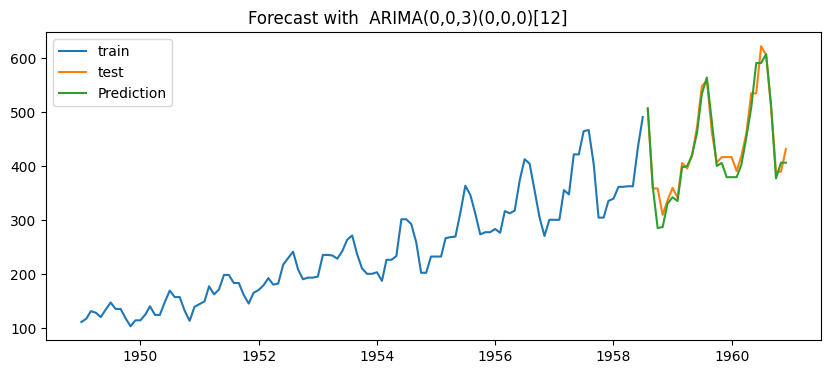

mean absolute error: 16.84
mean absolute percentage error: 4.0%
r2 score: 0.91
root mean squared error: 23.67


In [25]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),sarimax_pred, sarimax)

In [26]:
# Fine tunning 

fine_tuned_model= auto_arima(train['#Passengers'].ffill(),
                             X=exog_train,
                             m=12,
                             seasonal=True,
                             start_P=0, max_P= 5,
                             start_q=0, max_Q=5,
                             start_p=0, max_p=5,
                             start_Q=0, max_q=5,
                             d= 1,D=1, max_D=5, max_d=5,
                             n_jobs=-1,
                             maxiter=100,
                             stepwise=True,
                             trace=True,               
                          information_criterion='aic', 
                          suppress_warnings=True,
                          error_action='ignore')

c:\Users\MINE\AppData\Local\Programs\Python\Python311\Lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=871.112, Time=0.59 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=832.194, Time=6.04 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=7.02 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=867.763, Time=2.91 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=827.189, Time=17.96 sec
 ARIMA(1,1,0)(3,1,0)[12]             : AIC=829.189, Time=24.38 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=829.190, Time=12.79 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=828.758, Time=7.13 sec
 ARIMA(1,1,0)(3,1,1)[12]             : AIC=831.183, Time=25.81 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=840.093, Time=14.55 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=818.894, Time=15.77 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=832.010, Time=7.28 sec
 ARIMA(2,1,0)(3,1,0)[12]             : AIC=820.298, Time=26.85 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=820.199, Time=22.70 sec
 ARIMA(2,1,0)(1,1,1)[12]     

In [27]:
fine_tuned_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  115
Model:             SARIMAX(5, 1, 0)x(2, 1, 0, 12)   Log Likelihood                -382.061
Date:                            Sat, 08 Aug 2026   AIC                            806.122
Time:                                    09:11:47   BIC                            861.246
Sample:                                01-01-1949   HQIC                           828.443
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
month             -3.8406      1.259     -3.050      0.002      -6.309      -1.372
quater            17.8354      3.955      4.510      0.000      10.084      25.587
lag1              -0.6213      0.123     -5.071      0.000      -0.861      -0.381
lag2              -0.5475      0.092     -5.955      0.000      -0.728      -0.367
lag3              -0.2792      0.102     -2.738      0.006      -0.479      -0.079
lag6              -0.0183      0.062     -0.296      0.767      -0.140       0.103
lag12              0.0247      0.042      0.588      0.557      -0.058       0.107
rolling_mean3      2.1790      0.239      9.107      0.000       1.710       2.648
rolling_std3      -0.2691      0.133     -2.023      0.043      -0.530      -0.008
rolling_mean6      0.3021      0.147      2.059      0.039       0.015       0.590
rolling_std6       0.3348      0.170      1.974      0.048       0.002       0.667
rolling_mean12    -0.2234      0.227     -0.984      0.325      -0.668       0.222
rolling_std12     -0.5837      0.384     -1.520      0.129      -1.337       0.169
ar.L1             -1.2459      0.112    -11.136      0.000      -1.465      -1.027
ar.L2             -1.2086      0.178     -6.785      0.000      -1.558      -0.859
ar.L3             -1.0304      0.219     -4.705      0.000      -1.460      -0.601
ar.L4             -0.7711      0.201     -3.845      0.000      -1.164      -0.378
ar.L5             -0.3809      0.143     -2.658      0.008      -0.662      -0.100
ar.S.L12          -0.9608      0.147     -6.551      0.000      -1.248      -0.673
ar.S.L24          -0.5339      0.150     -3.554      0.000      -0.828      -0.239
sigma2            87.1895     14.473      6.024      0.000      58.824     115.555
===================================================================================
Ljung-Box (L1) (Q):                   0.51   Jarque-Bera (JB):                 3.89
Prob(Q):                              0.47   Prob(JB):                         0.14
Heteroskedasticity (H):               3.68   Skew:                            -0.16
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
fine_tuned_model.get_params

<bound method BaseEstimator.get_params of ARIMA(maxiter=100, order=(5, 1, 0), scoring_args={},
      seasonal_order=(2, 1, 0, 12), suppress_warnings=True,
      with_intercept=False)>

In [29]:
exog_test.shape

(29, 13)

In [30]:
test.shape

(29, 14)

In [31]:
forecast= fine_tuned_model.predict(n_periods=len(test), X= exog_test)

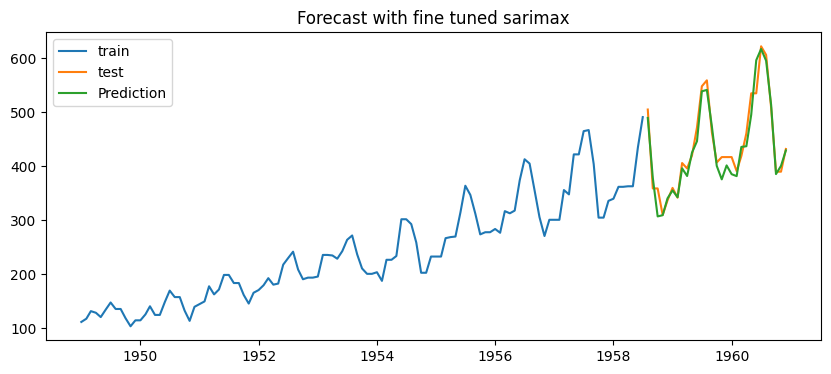

mean absolute error: 16.3
mean absolute percentage error: 4.0%
r2 score: 0.92
root mean squared error: 22.26


In [32]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),forecast, 'fine tuned sarimax')

In [33]:
# Future prediction model

final_model= ARIMA(order=(5, 1, 0), seasonal_order=(2, 1, 0, 12), maxiter=100)

In [34]:
df= df.asfreq('MS')
df_exog= df.drop(columns='#Passengers').bfill()

In [35]:
final_model.fit(y=df['#Passengers'].ffill(), X=df_exog)

c:\Users\MINE\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,"(5, ...)"
,seasonal_order,"(2, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,100
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


In [36]:
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  144
Model:             SARIMAX(5, 1, 0)x(2, 1, 0, 12)   Log Likelihood                -521.314
Date:                            Sat, 08 Aug 2026   AIC                           1086.627
Time:                                    09:12:11   BIC                           1149.882
Sample:                                01-01-1949   HQIC                          1112.330
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          1.6430      1.593      1.031      0.302      -1.479       4.765
month             -4.3354      1.636     -2.650      0.008      -7.542      -1.129
quater            16.9032      5.326      3.173      0.002       6.464      27.343
lag1              -0.5081      0.132     -3.864      0.000      -0.766      -0.250
lag2              -0.4632      0.079     -5.894      0.000      -0.617      -0.309
lag3              -0.2356      0.101     -2.327      0.020      -0.434      -0.037
lag6              -0.0304      0.046     -0.668      0.504      -0.120       0.059
lag12             -0.0260      0.044     -0.595      0.552      -0.112       0.060
rolling_mean3      1.9405      0.197      9.853      0.000       1.554       2.326
rolling_std3      -0.1672      0.082     -2.038      0.042      -0.328      -0.006
rolling_mean6      0.3346      0.181      1.846      0.065      -0.021       0.690
rolling_std6       0.1924      0.167      1.150      0.250      -0.136       0.520
rolling_mean12    -0.3535      0.214     -1.651      0.099      -0.773       0.066
rolling_std12     -0.6881      0.392     -1.756      0.079      -1.456       0.080
ar.L1             -1.2768      0.124    -10.296      0.000      -1.520      -1.034
ar.L2             -1.2692      0.220     -5.759      0.000      -1.701      -0.837
ar.L3             -1.0249      0.245     -4.178      0.000      -1.506      -0.544
ar.L4             -0.6164      0.186     -3.306      0.001      -0.982      -0.251
ar.L5             -0.3003      0.108     -2.773      0.006      -0.513      -0.088
ar.S.L12          -0.9667      0.131     -7.399      0.000      -1.223      -0.711
ar.S.L24          -0.6016      0.118     -5.095      0.000      -0.833      -0.370
sigma2           155.5208     25.591      6.077      0.000     105.364     205.678
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                41.40
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               8.44   Skew:                            -0.50
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
last_date= df.index[-1]
last_date

Timestamp('1960-12-01 00:00:00')

In [38]:
period= 24

future_dates= pd.date_range(
  start=last_date + pd.DateOffset(months=1),
  periods=period ,
  freq='MS'
)

In [39]:
future_dates

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01',
               '1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01', '1962-11-01', '1962-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [40]:
future_data= pd.DataFrame(index=future_dates)

In [41]:
last_value= df['#Passengers'].iloc[-1:].values.tolist()

In [42]:
last_value

[432.0]